# Binary Logistic Regression

## Types of Classification Models

* Logistic Regression
* K-Nearest Neighbor
* Support Vector (with Kernel Trick)
* Naive Bayes
* Decision Tree
* Random Forest

## Linear Regression

$y = \beta_0 + \beta_1X_1 + ... + \beta_nX_n$

          x         y
0 -2.260427 -2.241653
1 -0.365652 -0.958527
2 -0.175486 -0.379727
3  0.396733 -0.614502
4 -0.143675  0.095120

x, y scatter plot with line of best fit as per our line equation
y = -0.32342999751614443 + 0.6650247153097613X


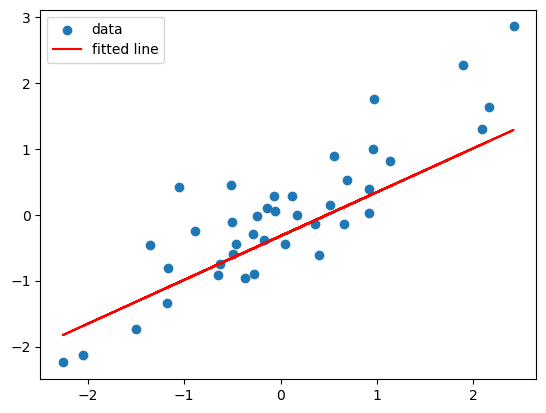

In [1]:
# create and train the model
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_regression(n_samples=50, n_features=1, noise=10)
df = pd.DataFrame.from_dict({'x': X.flatten(), 'y': y})

scaler = StandardScaler()
df[['x', 'y']] = scaler.fit_transform(df[['x', 'y']])
print(df.head())

# decision threshold = .5
df['class'] = df['y'].apply(lambda x: 0 if x <= 0 else 1)

X_train, X_test, y_train, y_test = train_test_split(df.drop(['y'], axis=1), df['y'], test_size=.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# test set prediction results
predictions = model.predict(X_test)
print('\nx, y scatter plot with line of best fit as per our line equation')
print(f'y = {model.intercept_} + {model.coef_[0]}X')

plt.scatter(X_train['x'], y_train, label='data')
plt.plot(X_train['x'], model.intercept_ + model.coef_[0] * X_train['x'], color='red', label='fitted line')
# plt.axhline(0.5, color='green', linestyle='dashed', label='threshold')
plt.legend();

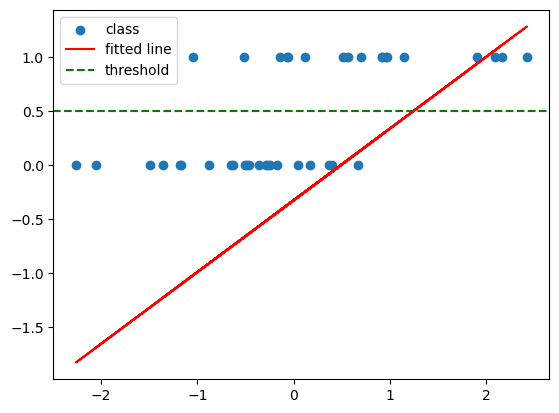

In [2]:
# does a line of best fit over a binary dependent variable make sense?
plt.scatter(X_train['x'], X_train['class'], label='class')
plt.plot(X_train['x'], model.intercept_ + model.coef_[0] * X_train['x'], color='red', label='fitted line')
plt.axhline(.5, color='green', linestyle='dashed', label='threshold')
# plt.axvline(0, color='gray', label='y=0')
plt.legend();

### The Sigmoid

Sigmoid curves are common in statistics as cumulative distribution functions (which go from 0 to 1), such as the integrals of the logistic density, the normal density, and Student's t probability density functions. The logistic sigmoid function is invertible, and its inverse is the logit function. 

https://en.wikipedia.org/wiki/Sigmoid_function

Sigmoidal growth is a modification of exponential growth in which the percent change gets smaller as the population approaches the carrying capacity.

http://matcmath.org/textbooks/quantitativereasoning/sigmoidal-growth/

          x  class
0 -2.260427      0
1 -0.365652      0
2 -0.175486      0
3  0.396733      0
4 -0.143675      1

An S curve that is bound by 1 and 0


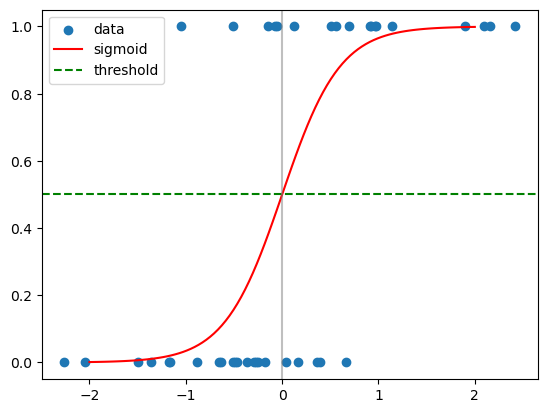

In [3]:
# what we'd really like
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# df with x and class
print(df.drop('y', axis=1).head())

x = np.linspace(-2, 2, 100)
s = .3 # scale parameter
print('\nAn S curve that is bound by 1 and 0')
plt.scatter(X_train['x'], X_train['class'], label='data')
plt.plot(x, 1 / (1 + np.exp(-(np.mean(x)/s + (1/s)*x))), color='red', label='sigmoid')
plt.axhline(.5, color='green', linestyle='dashed', label='threshold')
plt.axvline(0, color='gray', alpha=0.5)
plt.legend()
plt.show()

### Probability

$P(y=1) = \beta_0 + \beta_1 X$

The probability of y = 1 is determined by a threshold and in this equation, x is unbounded, $(-\infty, +\infty)$, on the x axis, but y is either 0 or 1, and not very informative in regards to x and our threshold. With binary classification we want to show a better relationship with x. 

### What is this Thing Called Threshold?

Logistic regression returns a probability. You can use the returned probability "as is" (for example, the probability that the user will click on this ad is 0.00023) or convert the returned probability to a binary value (for example, this email is spam).

A logistic regression model that returns 0.9995 for a particular email message is predicting that it is very likely to be spam. Conversely, another email message with a prediction score of 0.0003 on that same logistic regression model is very likely not spam. However, what about an email message with a prediction score of 0.6? In order to map a logistic regression value to a binary category, you must define a classification threshold (also called the decision threshold). A value above that threshold indicates "spam"; a value below indicates "not spam." It is tempting to assume that the classification threshold should always be 0.5, but thresholds are problem-dependent, and are therefore values that you must tune.

https://developers.google.com/machine-learning/crash-course/classification/thresholding

**Review our line of best fit given x and y**


x, y scatter plot with line of best fit as per our line equation
y = -0.32342999751614443 + 0.6650247153097613X


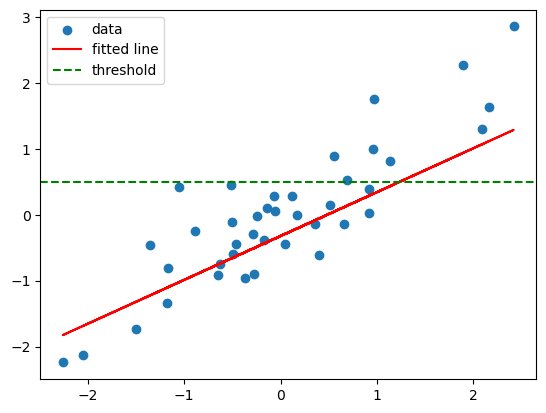

In [4]:
print('\nx, y scatter plot with line of best fit as per our line equation')
print(f'y = {model.intercept_} + {model.coef_[0]}X')

plt.scatter(X_train['x'], y_train, label='data')
plt.plot(X_train['x'], model.intercept_ + model.coef_[0] * X_train['x'], color='red', label='fitted line')
plt.axhline(0.5, color='green', linestyle='dashed', label='threshold')
plt.legend();

### Odds

Odds provide a measure of the likelihood of a particular outcome. They are calculated as the ratio of the number of events that produce that outcome to the number that do not.

https://en.wikipedia.org/wiki/Odds

$\large{\frac{p}{1 - p}} = \beta_0 + \beta_1 X$

Odds are positive so we have a range of 0, $+ \infty$ so we use log

In [5]:
# https://www.statisticshowto.com/log-odds/
import pandas as pd
import math

print('Defining odds based on a probability represented by a decimals')
d = {'Probs': [.1, .2, .3, .4, .5, .6, .7, .8, .9]}
probs = pd.DataFrame(d)
probs['Odds'] = probs['Probs']/(1 - probs['Probs'])
probs.head(9)

Defining odds based on a probability represented by a decimals


,Probs,Odds
0,0.1,0.111111
1,0.2,0.250000
2,0.3,0.428571
3,0.4,0.666667
4,0.5,1.000000
5,0.6,1.500000
6,0.7,2.333333
7,0.8,4.000000
8,0.9,9.000000


### Log Odds

We use the log of odds so that we can get to $(-\infty, +\infty)$

$\large{log(\frac{p}{1 - p}}) = \beta_0 + \beta_1 X$

Now our range is unrestricted $- \infty, + \infty$ where the odds for and odds against meet at 0 with potential symmetrical range 0 to infinity. See images at https://towardsdatascience.com/https-towardsdatascience-com-what-and-why-of-log-odds-64ba988bf704

In binomial logistic regression, the dependent variable takes only two values, which can be coded 0 and 1. So, it can't be that $Y=b0+b1X$ because that could result in any value. The logit transformation solves this problem.

We take the odds to make the value continuous. We take the odds ratio to get a parameter estimate and we take the log of that ratio to make the variable range from negative infinity to infinity and be symmetric around 0 instead of 1.

Peter Flom (https://stats.stackexchange.com/users/686/peter-flom), Why $\log(\frac{p}{1-p}) = b_0+b_1x $ in Logistic regression, URL (version: 2017-09-25): https://stats.stackexchange.com/q/304844

In [6]:
# log odds example
import math

p = .2
odds = p/(1-p)
print('.2/.8 =', odds)
print('log(.25) =', math.log(odds))

.2/.8 = 0.25
log(.25) = -1.3862943611198906


In [7]:
# add log odds to our probs dataframe
probs['Log Odds'] = probs['Odds'].apply(lambda x: math.log(x))
probs.head(9)

,Probs,Odds,Log Odds
0,0.1,0.111111,-2.197225
1,0.2,0.250000,-1.386294
2,0.3,0.428571,-0.847298
3,0.4,0.666667,-0.405465
4,0.5,1.000000,0.000000
5,0.6,1.500000,0.405465
6,0.7,2.333333,0.847298
7,0.8,4.000000,1.386294
8,0.9,9.000000,2.197225


### Logistic Function Proof

* $p(y=1) = \beta_0 + \beta_1x$
* $\frac{p}{1 - p} = \beta_0 + \beta_1x$ # bounded by 0
* $log(\frac{p}{1 - p}) = \beta_0 + \beta_1x$ # what we want because it is unbounded
* $e^{ln[\frac{p}{1-p}]} = e^{\beta_0 + \beta_1x}$
* $\frac{p}{1-p} = e^{\beta_0 + \beta_1x}$
* $p = e^{\beta_0 + \beta_1x} - pe^{\beta_0 + \beta_1x}$
* $= p[\frac{e^{\beta_0 + \beta_1x}}{p} - e^{\beta_0 + \beta_1x}]$
* $p[1 + e^{\beta_0 + \beta_1x}] = e^{\beta_0 + \beta_1x}$
* $= \frac{e^{\beta_0 + \beta_1x}}{1 + e^{\beta_0 + \beta_1x}}$
* $= \large{\frac{1}{1 + e^{-(\beta_0 + \beta_1x + ...)}}}$
* $= \large{\frac{1}{1 + e^{-(x)}}}$

### Why the Exponential

Exponentials are also used to express growth which is instrumental with the sigmoid function. The function $y = e^x$ gives a curve at which the slope at any value x is also the value of y, which means the derivative is equal to the function itself, or $f'(e^x) = e^x$. 

https://www.ml-science.com/eulers-number

### Summary

Logistic functions are used in logistic regression to model how the probability $p$ of an event may be affected by one or more explanatory variables: an example would be to have the model $p = f(a + bx)$, where $x$ is the explanatory variable, $a$ and $b$ are model parameters to be fitted, and $f$ is the standard logistic function.

https://en.wikipedia.org/wiki/Logistic_function#In_statistics_and_machine_learning

* $f(x) = \large{\frac{1}{1 + e^{-(x)}}}$

https://www.analyticsvidhya.com/blog/2021/08/conceptual-understanding-of-logistic-regression-for-data-science-beginners/

## Make Classification

Generate some data with a binary class

In [8]:
# Create dataset
import pandas as pd
from sklearn.datasets import make_classification

n = 1000 # number of observations
f = 2 # number of features
inform = 2 # number of meaningful features

# unpack X and y
features, binary_class = make_classification(n_samples=n, n_features=f,  
                                             n_informative=inform, n_redundant=0, 
                                             n_clusters_per_class=1, random_state=42)

# Create a dataframe of the features and add the binary class (label, output)
df = pd.DataFrame(features)
df.columns = ['Feature_1', 'Feature_2']
df['Class'] = binary_class
df.head()

,Feature_1,Feature_2,Class
0,0.601034,1.535353,1
1,0.755945,-1.172352,0
2,1.354479,-0.948528,0
3,3.103090,0.233485,0
4,0.753178,0.787514,1


In [9]:
# get our parameters
from statsmodels.formula.api import logit

model = logit(formula='Class ~ Feature_1 + Feature_2', data=df).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.242088
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Class   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Tue, 13 Jun 2023   Pseudo R-squ.:                  0.6507
Time:                        16:56:34   Log-Likelihood:                -242.09
converged:                       True   LL-Null:                       -693.15
Covariance Type:            nonrobust   LLR p-value:                1.283e-196
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1197      0.365      3.070      0.002       0.405       1.834
Feature_1     -0.4561      0.171     -2.673      0.008      -0.790      -0.122
Feature_2      3.4780      0.237     14.649      0.000       3.013       3.943
==============================================================================
"""

### Logistic Model

In statistics, the logistic model (or logit model) is a statistical model that models the probability of an event taking place by having the log-odds for the event be a linear combination of one or more independent variables. In regression analysis, logistic regression (or logit regression) is estimating the parameters of a logistic model (the coefficients in the linear combination). 

* $p = \large{\frac{1}{1 + e^{-(\beta_0 + \beta_1x)}}}$

* https://en.wikipedia.org/wiki/Logistic_regression
* https://en.m.wikipedia.org/wiki/Logistic_function

In [10]:
import numpy as np

print(model.params)
def logistic_function(row):
    b0 = model.params.Intercept
    b1 = model.params.Feature_1
    b2 = model.params.Feature_2
    
    x1 = row['Feature_1']
    x2 = row['Feature_2']
    
    return 1 / (1 + np.exp(-(b0+(b1*x1)+(b2*x2))))

df['p'] = df.apply(logistic_function, axis=1)
df['Odds'] = df['p']/(1 - df['p'])
df['Log Odds'] = df['Odds'].apply(lambda x: math.log(x))
df['Predicted'] =  df['p'].apply(lambda x: 0 if x < .5 else 1)
df.head()

Intercept    1.119669
Feature_1   -0.456101
Feature_2    3.478029
dtype: float64


,Feature_1,Feature_2,Class,p,Odds,Log Odds,Predicted
0,0.601034,1.535353,1,0.997945,485.673902,6.185537,1
1,0.755945,-1.172352,0,0.035482,0.036788,-3.302593,0
2,1.354479,-0.948528,0,0.057480,0.060985,-2.797120,0
3,3.103090,0.233485,0,0.626309,1.676007,0.516414,1
4,0.753178,0.787514,1,0.971116,33.620678,3.515141,1


### Logit

A Logit function, the inverse of the logistic sigmoid, also known as the log-odds function, is a function that represents probability values from 0 to 1, and negative infinity to infinity.

* https://deepai.org/machine-learning-glossary-and-terms/logit
* https://en.m.wikipedia.org/wiki/Logit

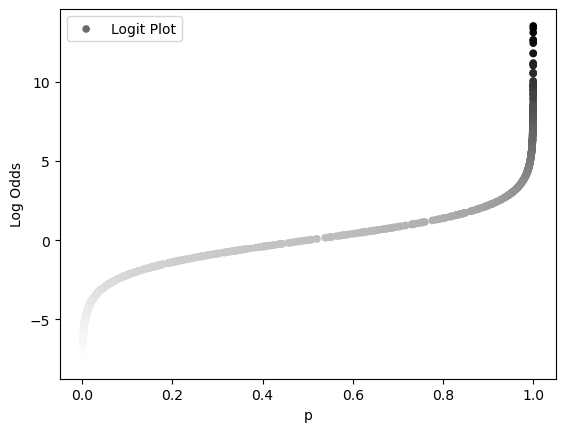

In [11]:
# logit curve
import matplotlib.pyplot as plt

df.plot.scatter(x='p', y='Log Odds', label='Logit Plot', c=df['Log Odds'])
plt.show()

### Logit vs Sigmoid

The inverse of the logit curve is the inverse-logit or sigmoid function. The sigmoid function transforms the numbers ( -∞ to +∞ ) back to values between 0 and 1.

* https://ajaytech.co/python-logistic-regression/

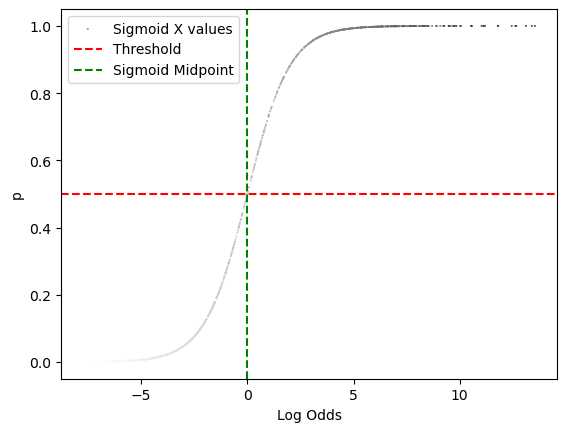

In [12]:
import matplotlib.pyplot as plt

df.plot.scatter(x='Log Odds', y='p', marker='.', s=.5, label='Sigmoid X values', c=df['Log Odds'])
plt.axhline(y=.5, color='red', linestyle='dashed', label='Threshold')
plt.axvline(x=0, color='green', linestyle='dashed', label='Sigmoid Midpoint')
plt.legend()
plt.show()

* Logistic regression algorithm: $f(x) = \large{\frac{1}{1 + e^{-x}}}$
* x = $\beta_0 + \beta_1X_1 + \beta_2X_2$
* If $x > 0$ then $\frac{1}{1 + e^{-x}} > .5$
* If $x < 0$ then $\frac{1}{1 + e^{-x}} < .5$